### Importy

In [36]:
from time import perf_counter                                                                                                                         
import pandas as pd                                                                        
import numpy as np                                                                         
from scipy.io import arff                                                                  
                                                                                                                                          
import matplotlib.pyplot as plt                                                            
import seaborn as sns                                                                                            
from sklearn.preprocessing import StandardScaler, MinMaxScaler                                                                                 
from sklearn.cluster import KMeans                                                         
from sklearn.cluster import AgglomerativeClustering                                                                              
from sklearn.metrics import silhouette_score                                               
from sklearn.metrics.cluster import contingency_matrix 
                                                                                               

In [37]:
source = arff.loadarff('Dry_Bean_Dataset.arff')
df = pd.DataFrame(source[0])
if df['Class'].dtype == object:                                                                                           
        try:                                                                                                                  
            df['Class'] = df['Class'].str.decode('utf-8')                                                                     
        except AttributeError:                                                                                                
            pass
print(f"Rozmiar danych: {df.shape}")

Rozmiar danych: (13611, 17)


In [38]:
df.info(verbose = True)

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  float64
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  float64
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(16), str(1)


In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,13611.0,53048.284549,29324.095717,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,13611.0,855.283459,214.289696,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,13611.0,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,13611.0,202.270714,44.970091,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,13611.0,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,13611.0,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,13611.0,53768.200206,29774.915817,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,13611.0,253.064220,59.177120,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,13611.0,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,13611.0,0.987143,0.004660,0.919246,0.985670,0.988283,0.990013,0.994677


### Balans klasy docelowej

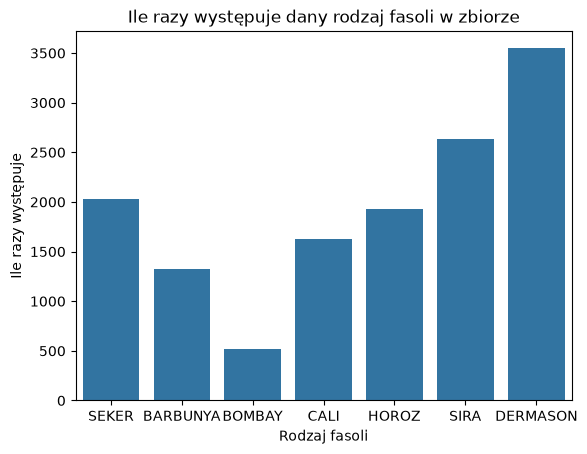

In [40]:
sns.countplot(x = df["Class"], data = df)
plt.title("Ile razy występuje dany rodzaj fasoli w zbiorze")
plt.xlabel("Rodzaj fasoli")
plt.ylabel("Ile razy występuje")
plt.show()

- Najczęściej występuje Dermason, lecz nie ma on jakieś szczególnej przewagi. Jako, że celem laboratorium jest uczenie nienadzorowane, to i tak nie moglibyśmy stosować np Smote. 

### Braki

In [41]:
assert sum(df.isna().sum()) == 0

- Nie występują braki.

In [42]:
df.drop_duplicates(inplace = True)

- Usuwamy duplikaty.

### Opis cech zbioru Dry Bean Dataset

Poniższa tabela przedstawia wszystkie cechy ziaren fasoli zmierzone na podstawie analizy obrazu (pikseli). Wszystkie wartości numeryczne pomagają algorytmom zidentyfikować dany kształt.

| Nazwa cechy | Opis / Znaczenie | Typ danych |
| :--- | :--- | :--- |
| **Area** | Pole powierzchni ziarna (liczba pikseli w jego granicach). | `float` (ciągła) |
| **Perimeter** | Obwód ziarna (długość jego granicy). | `float` (ciągła) |
| **MajorAxisLength** | Długość osi wielkiej (najdłuższa linia wewnątrz ziarna). | `float` (ciągła) |
| **MinorAxisLength** | Długość osi małej (najdłuższa prostopadła do osi wielkiej). | `float` (ciągła) |
| **AspectRation** | Współczynnik proporcji (stosunek osi wielkiej do małej). | `float` (ciągła) |
| **Eccentricity** | Mimośród (jak bardzo elipsa przypomina okrąg). | `float` (ciągła) |
| **ConvexArea** | Pole otoczki wypukłej (najmniejszy wielokąt wypukły otaczający ziarno). | `float` (ciągła) |
| **EquivDiameter** | Średnica zastępcza (średnica koła o takim samym polu jak ziarno). | `float` (ciągła) |
| **Extent** | Stopień wypełnienia (stosunek pola ziarna do pola ramki ograniczającej / bounding box). | `float` (ciągła) |
| **Solidity** | Zwartość / Solidność (stosunek pola ziarna do pola jego otoczki wypukłej). | `float` (ciągła) |
| **roundness** | Okrągłość (obliczana ze wzoru z użyciem obwodu i pola powierzchni). | `float` (ciągła) |
| **Compactness** | Kompaktowość (współczynnik mierzący jak bardzo obiekt jest "zbity"). | `float` (ciągła) |
| **ShapeFactor1...4** | Zestaw 4 geometrycznych współczynników kształtu wyliczonych przez autorów zbioru. | `float` (ciągła) |
| **Class** | Gatunek ziarna (Seker, Barbunya, Bombay, Cali, Dermason, Horoz, Sira). **Nieużywane w samej klasteryzacji.** | `string` (kategoryczna) |


### Badanie korelacji

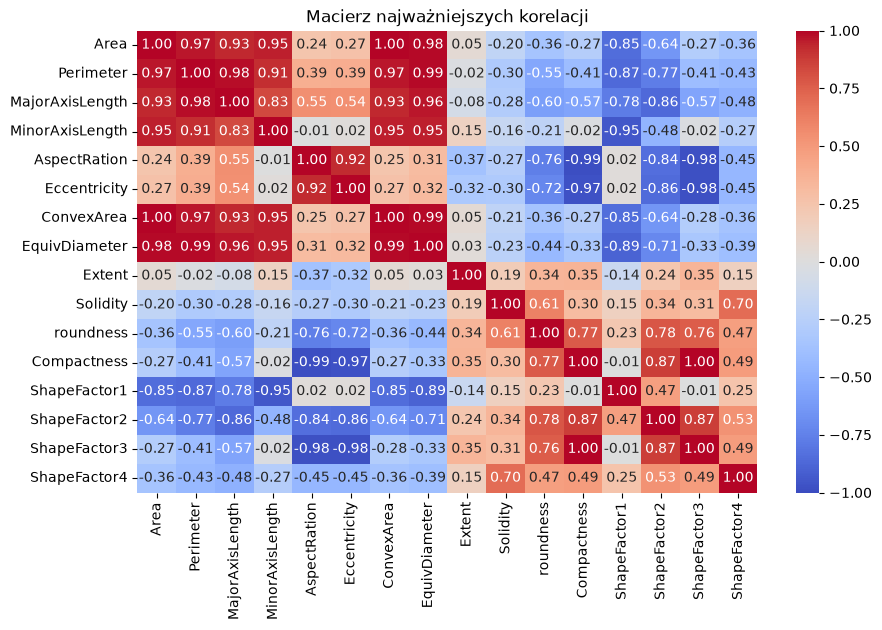

In [43]:
plt.figure(figsize = (10,6))
sns.heatmap(
    data = df.corr(numeric_only = True), 
    vmin = -1,
    vmax = 1,
    cmap = "coolwarm",
    annot = True,
    fmt = ".2f"
)
plt.title("Macierz najważniejszych korelacji")
plt.show()

### Ciekawe zależności

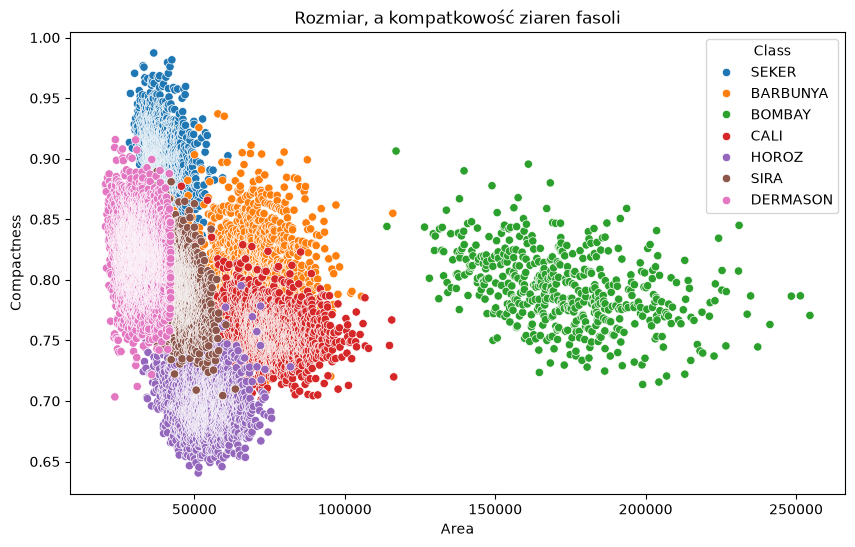

In [44]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = df, x = 'Area', y = 'Compactness', hue = 'Class')
plt.title("Rozmiar, a kompatkowość ziaren fasoli")
plt.show()

- Ewidentnie tworzą się klastry.

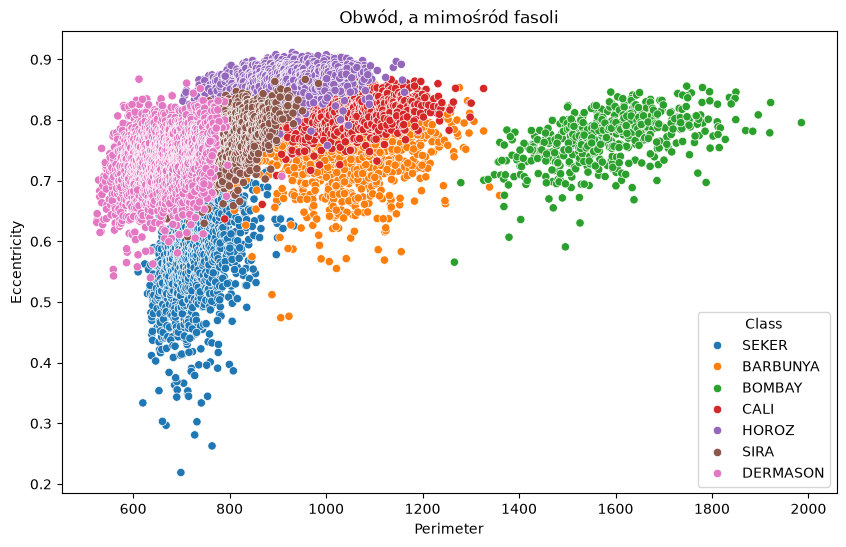

In [45]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = df, x = 'Perimeter', y = 'Eccentricity', hue = 'Class')
plt.title("Obwód, a mimośród fasoli")
plt.show()

- Również się tworzą klastry.

### Preprocessing

In [46]:
y = df['Class']
X = df.drop(columns=['Class'])

scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_arr, columns=X.columns)
print("Dane po standaryzacji (średnia bliska 0, odchylenie 1):")                                                          
display(X_scaled.head())                                                                                                  


Dane po standaryzacji (średnia bliska 0, odchylenie 1):


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,-0.838800,-1.139663,-1.301976,-0.632111,-1.565363,-2.182833,-0.839489,-1.060491,0.287981,0.366476,1.420346,1.838628,0.681918,2.398280,1.924811,0.838679
1,-0.827266,-1.010529,-1.391169,-0.435758,-1.972460,-3.685504,-0.824175,-1.041410,0.697598,-0.465886,0.224987,2.497622,0.369552,3.097471,2.691446,0.771141
2,-0.805287,-1.075303,-1.247807,-0.586775,-1.514305,-2.042229,-0.806818,-1.005357,0.577958,0.517614,1.248979,1.764053,0.604373,2.231086,1.840150,0.917418
3,-0.783920,-0.973894,-1.274241,-0.440595,-1.742960,-2.740196,-0.772170,-0.970686,0.671302,-2.248692,0.509588,2.082211,0.403254,2.511258,2.204306,-0.202373
4,-0.779429,-1.093821,-1.375750,-0.268281,-2.121534,-4.535823,-0.782457,-0.963445,0.475476,0.804605,1.872434,2.768598,0.120215,3.267675,3.016333,0.940406


#### Zapis do pliku

In [47]:
df_ready = X_scaled.copy()                                                                                                
df_ready['Class'] = y.values      
df_ready.to_csv('Dry_Bean_preprocessed.csv', index=False)                                                                                        